# Toronto Bike Share Usage Analysis (Toronto, 2025)

This project analyzes seasonal and behavioural patterns in bike share usage using trip-level data from 2025.

## loading data

### Data Preprocessing

The dataset was preprocessed in a separate Python script (`main.py`). 

This included:
- Combining 12 monthly datasets into a single dataset (~7.8 million records)
- Cleaning and standardizing column names
- Converting time columns (`start_time`, `end_time`) to datetime format
- Creating additional features such as `month`, `hour`, and `day_of_week`

The cleaned dataset is loaded here for analysis.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_bikeshare_2025.csv")

df.head()

,trip_id,trip_duration,start_station_id,start_time,start_station_name,end_station_id,end_time,end_station_name,bike_id,user_type,bike_model,month,hour,day_of_week,month_name
0,34637659,193,7192.0,2025-01-01 00:02:15,Harbord St / Clinton St,7155.0,2025-01-01 00:05:28,Harbord St / Clinton St,4422,Member,ICONIC,1,0,Wednesday,January
1,34637678,464,7508.0,2025-01-01 00:14:07,Berkeley St / Dundas St E - SMART,7042.0,2025-01-01 00:21:51,Berkeley St / Dundas St E - SMART,4618,Member,ICONIC,1,0,Wednesday,January
2,34637663,770,7094.0,2025-01-01 00:07:21,14 Arundel Ave,7777.0,2025-01-01 00:20:11,14 Arundel Ave,7975,Member,EFIT G5,1,0,Wednesday,January
3,34637679,559,7032.0,2025-01-01 00:14:09,Augusta Ave / Dundas St W,7541.0,2025-01-01 00:23:28,Augusta Ave / Dundas St W,3179,Member,ICONIC,1,0,Wednesday,January
4,34637658,116,7017.0,2025-01-01 00:02:13,Widmer St / Adelaide St W - SMART,7102.0,2025-01-01 00:04:09,Widmer St / Adelaide St W - SMART,3177,Member,ICONIC,1,0,Wednesday,January


In [7]:
df['start_time'] = pd.to_datetime(df['start_time']) 
df['month'] = df['start_time'].dt.month

## SEASONAL ANALYSIS

To understand how bike usage changes throughout the year, trip data was aggregated by month.
This allows us to identify seasonal patterns,

In [13]:
#Aggregate
monthly_counts = df.groupby('month')['trip_id'].count().sort_index()
monthly_counts

month
1      202946
2      125670
3      312178
4      471525
5      699461
6      980624
7     1192062
8     1164697
9     1062001
10     872482
11     511934
12     216940
Name: trip_id, dtype: int64

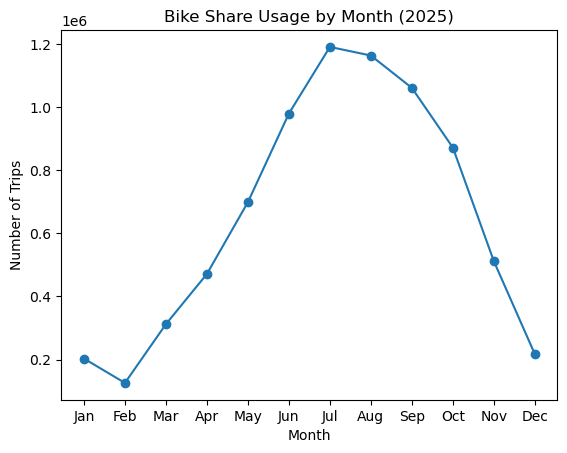

In [11]:
monthly_counts.plot(kind='line', marker='o')

plt.title("Bike Share Usage by Month (2025)")
plt.xlabel("Month")
plt.ylabel("Number of Trips")

plt.xticks(
    ticks=range(1, 13),
    labels=["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.show()

### Key Insight

Bike share usage in Toronto shows strong seasonality. Usage is lowest during winter months, particularly February, and increases steadily through spring. 

Usage peaks in July, with over 1.1 million trips, before gradually declining through fall and dropping again in winter. This indicates that bike usage is highly influenced by seasonal and weather conditions.

## HOURLY ANALYSIS

To understand daily usage behavior, trips were aggregated by hour of the day.

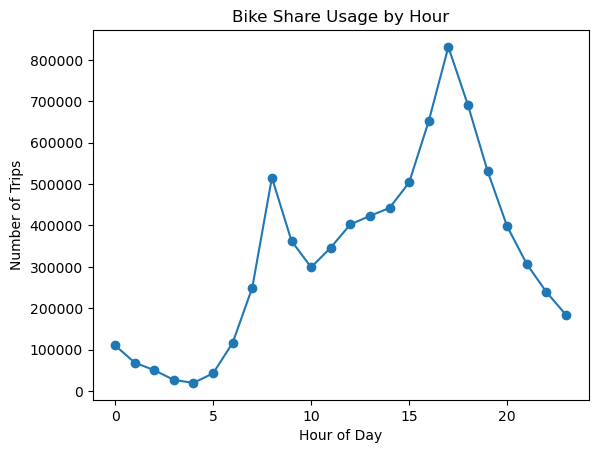

In [15]:
hourly_counts = df.groupby('hour')['trip_id'].count()

hourly_counts.plot(kind='line', marker='o')
plt.title("Bike Share Usage by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

### Insight

Bike share usage shows clear daily patterns, with two prominent peaks. 
The first peak occurs during the morning hours (around 8–9 AM), while the second and higher peak occurs in the late afternoon to early evening (around 5–6 PM). 
This pattern suggests that bike share usage is strongly driven by commuting behavior,
with users traveling to and from work during peak hours.

## USER TYPE ANALYSIS
To understand the distribution of different user types, trips were grouped by user category.

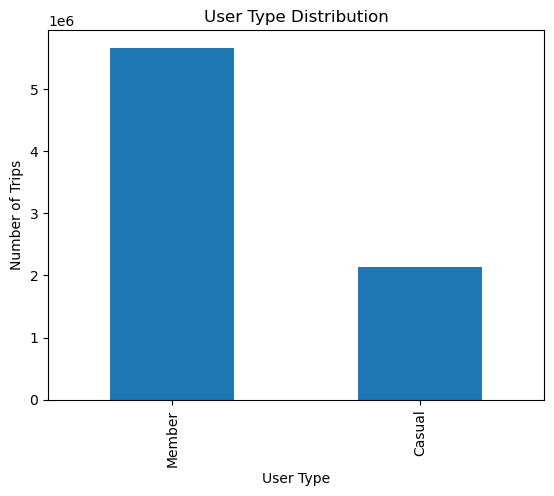

In [17]:
df['user_type'].value_counts().plot(kind='bar')
plt.title("User Type Distribution")
plt.xlabel("User Type")
plt.ylabel("Number of Trips")
plt.show()

### Insight

Bike share usage is dominated by annual members, indicating a strong base of recurring users. 
Casual usage is comparatively lower, suggesting that the system is primarily utilized for consistent, routine travel rather than occasional or recreational use.